Downloading...
From: https://drive.google.com/uc?id=1BJ7eIQVOrnEP-v6JctC54TI_c2VlKtDf
To: /content/data_train.csv
100%|██████████| 75.4M/75.4M [00:00<00:00, 76.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1FpUfMWi0LcR0SxCQg9cdcWjcuezKafuL
To: /content/target_train.csv
100%|██████████| 68.8k/68.8k [00:00<00:00, 23.3MB/s]


DATA columns: Index(['datetime', 'telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3',
       'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7',
       'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11',
       'telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15'],
      dtype='object')
TARGET columns: Index(['Дата', 'target'], dtype='object')

=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 319546 entries, 2019-03-01 00:01:00 to 2019-10-07 19:58:00
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   telemetry_0   319529 non-null  float64
 1   telemetry_1   319530 non-null  float64
 2   telemetry_2   319530 non-null  float64
 3   telemetry_3   319530 non-null  float64
 4   telemetry_4   319413 non-null  float64
 5   telemetry_5   319529 non-null  float64
 6   telemetry_6   319530 non-null  float64
 7   telemetry_7   319530 non-null  float64
 8   telemetry_

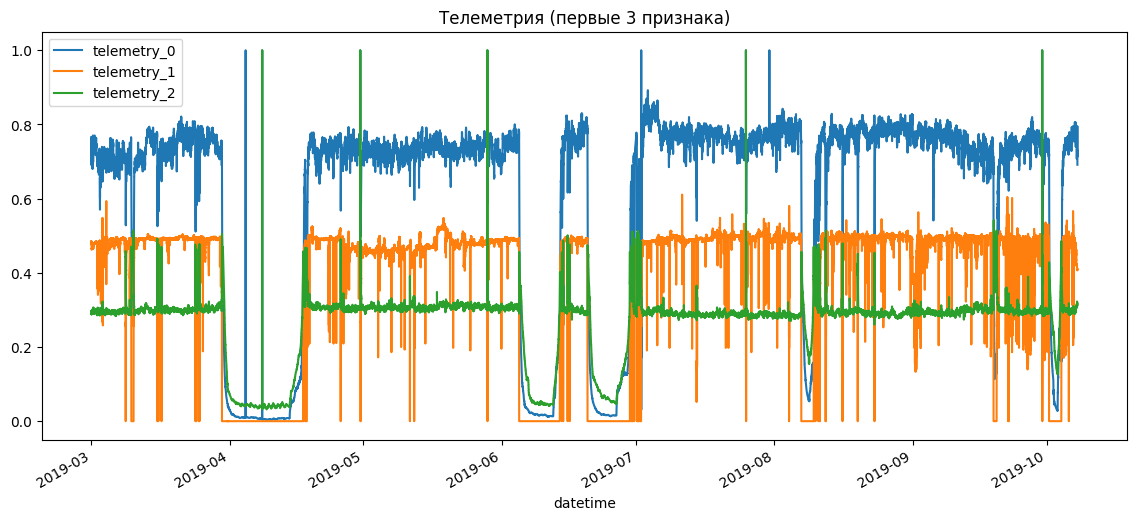

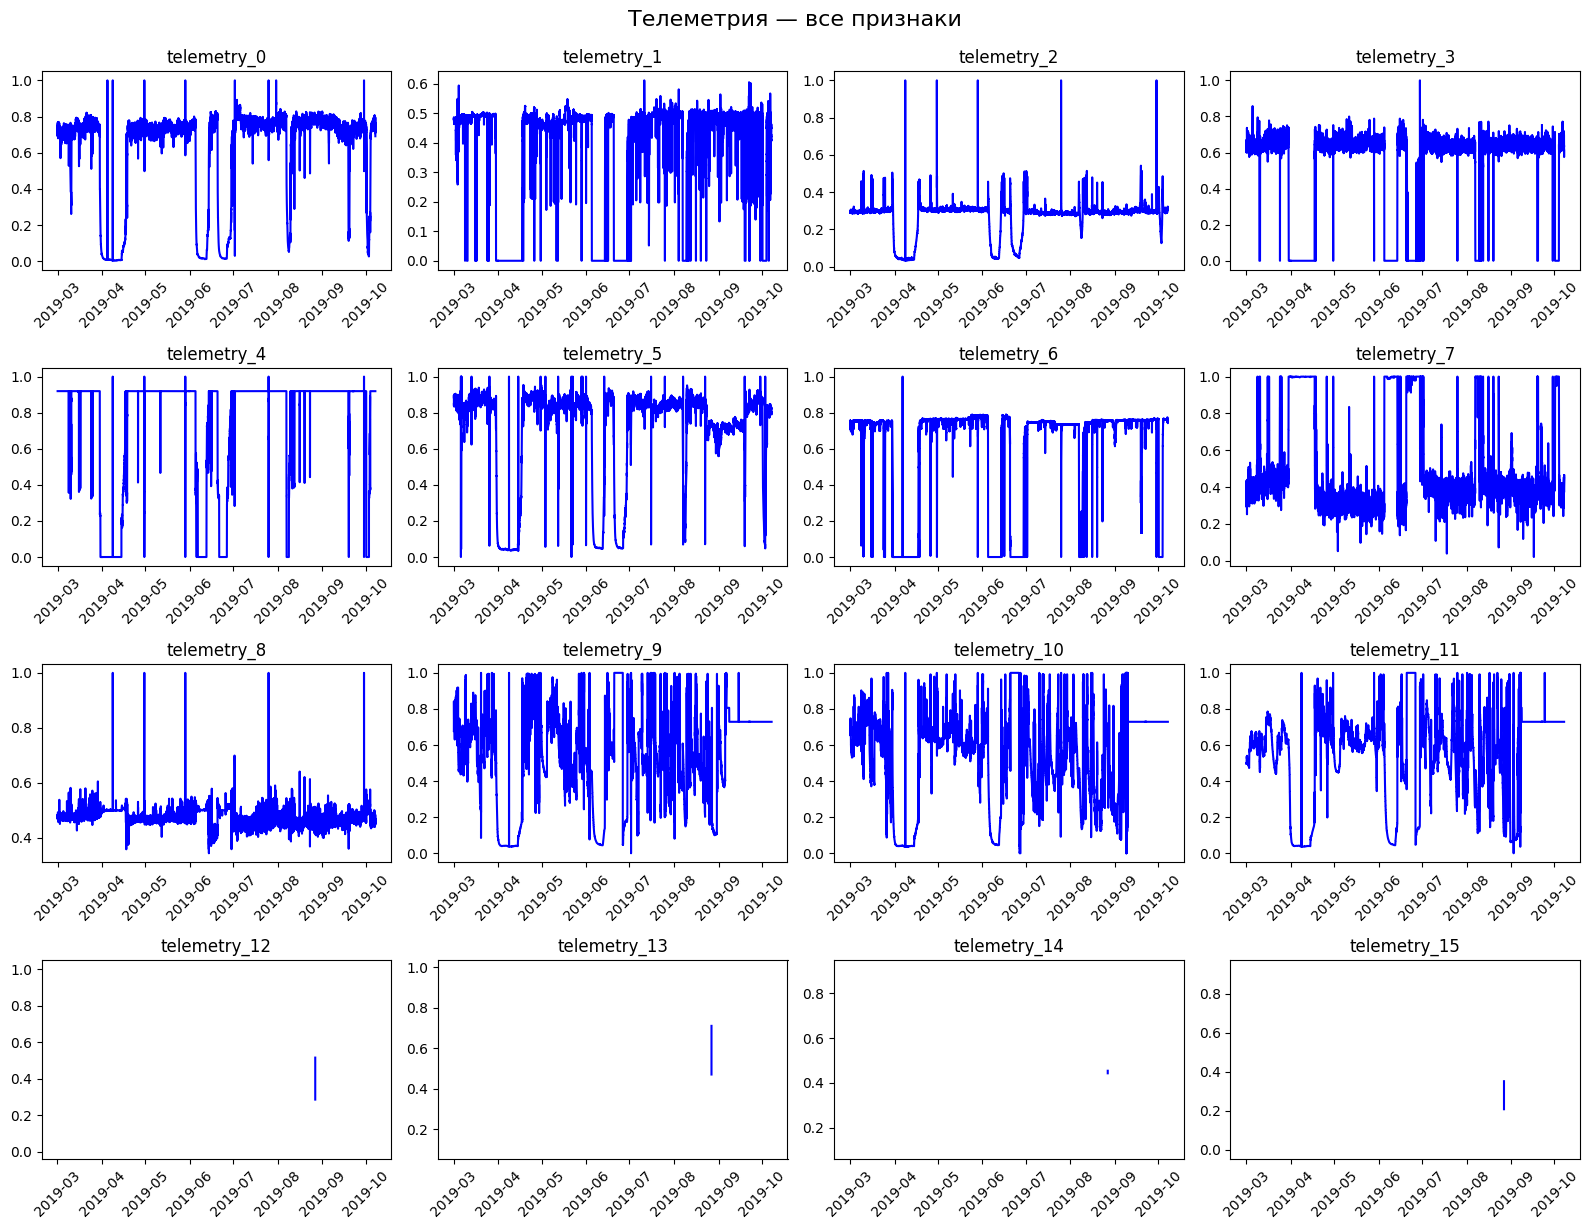

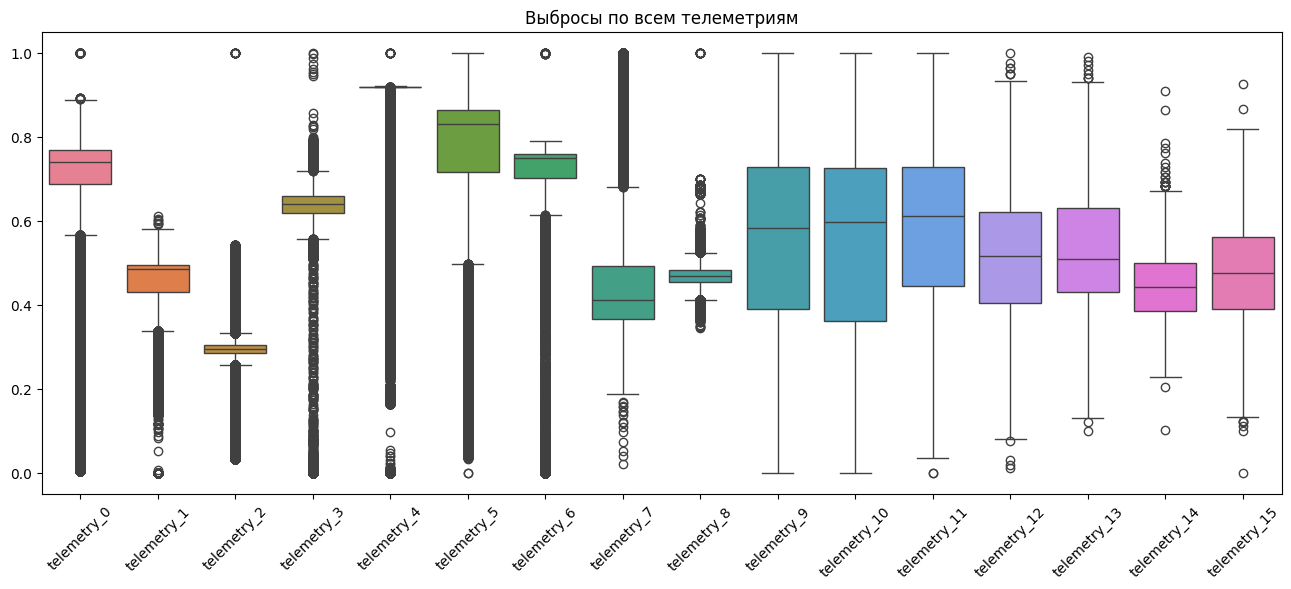

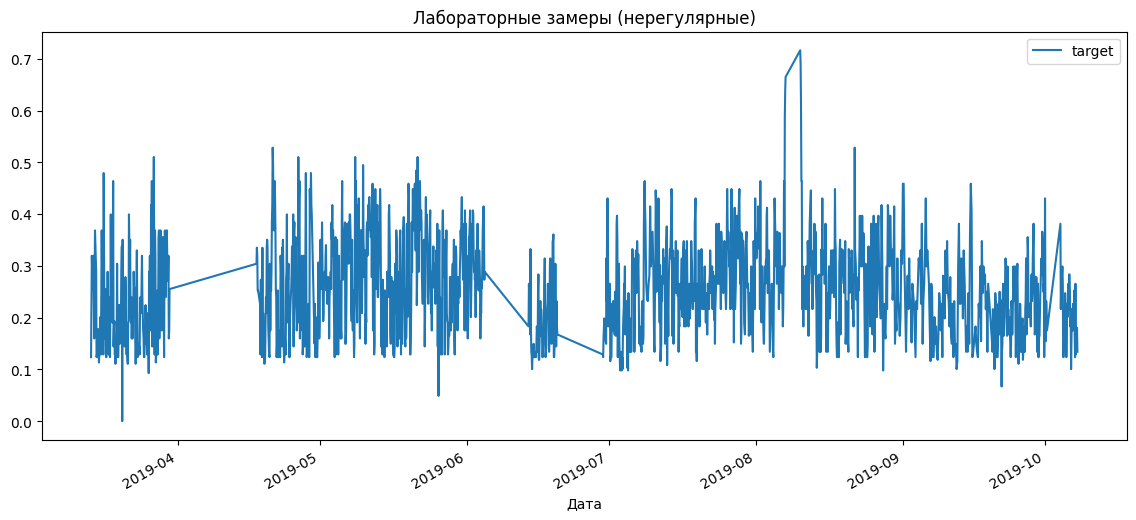


Частота DATA: None
Частота TARGET: None


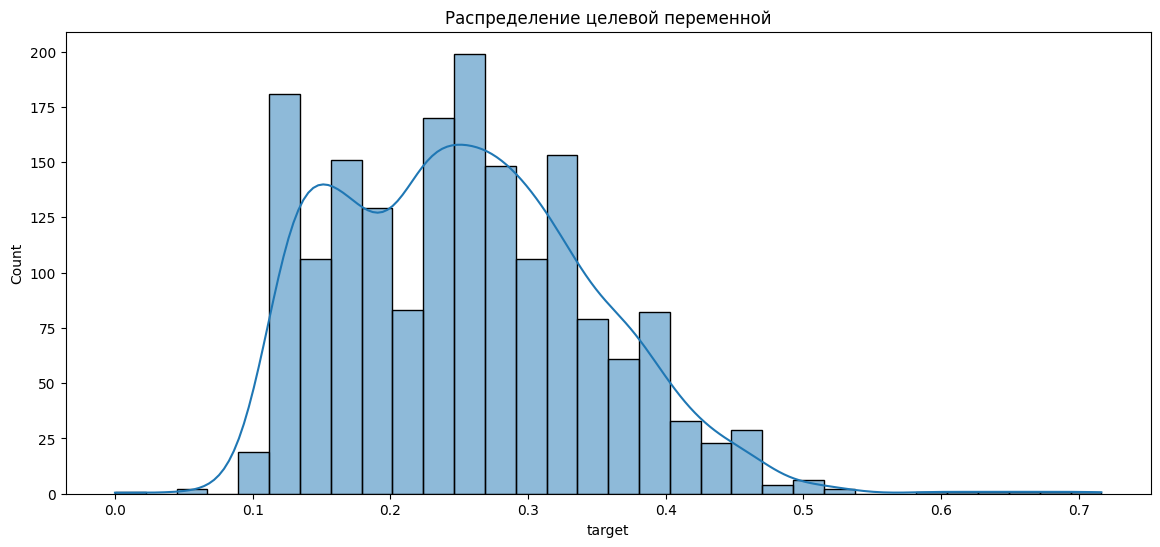

In [42]:
# ============================================
# 2.1 Разведочный анализ данных (EDA)
# Шаг 1: Загрузка + подготовка + базовый анализ
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 6)

# ==============================
# Установка gdown
# ==============================
!pip install --quiet gdown
import gdown

# ==============================
# ID файлов
# ==============================
data_id = "1BJ7eIQVOrnEP-v6JctC54TI_c2VlKtDf"
target_id = "1FpUfMWi0LcR0SxCQg9cdcWjcuezKafuL"

# ==============================
# Загрузка данных
# ==============================
gdown.download(f"https://drive.google.com/uc?id={data_id}", "data_train.csv", quiet=False)
gdown.download(f"https://drive.google.com/uc?id={target_id}", "target_train.csv", quiet=False)

# ==============================
# Чтение CSV
# ==============================
data = pd.read_csv("data_train.csv")
target = pd.read_csv("target_train.csv")

# ==============================
# Проверка колонок
# ==============================
print("DATA columns:", data.columns)
print("TARGET columns:", target.columns)

# ==============================
# Приведение времени
# ==============================
data['datetime'] = pd.to_datetime(data['datetime'])
data.set_index('datetime', inplace=True)

target['Дата'] = pd.to_datetime(target['Дата'])
target.set_index('Дата', inplace=True)

# ==============================
# Проверка структуры
# ==============================
print("\n=== DATA INFO ===")
print(data.info())

print("\n=== TARGET INFO ===")
print(target.info())

# ==============================
# Пропуски
# ==============================
print("\nПропуски в DATA:\n", data.isnull().sum().sort_values(ascending=False).head())
print("\nПропуски в TARGET:\n", target.isnull().sum())

# ==============================
# Базовая статистика
# ==============================
print("\nСтатистика DATA:\n", data.describe().T.head())
print("\nСтатистика TARGET:\n", target.describe())

# ==============================
# Визуализация телеметрии (первые 3 признака)
# ==============================
data.iloc[:, :3].plot(title="Телеметрия (первые 3 признака)")
plt.show()

# ============================================
# Визуализация всех признаков телеметрии
# ============================================
plt.figure(figsize=(16, 12))
for i, col in enumerate(data.columns, 1):
    plt.subplot(4, 4, i)
    plt.plot(data.index, data[col], color='blue')
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.suptitle("Телеметрия — все признаки", y=1.02, fontsize=16)
plt.show()

# ============================================
# Boxplot для выявления выбросов
# ============================================
plt.figure(figsize=(16, 6))
sns.boxplot(data=data)
plt.title("Выбросы по всем телеметриям")
plt.xticks(rotation=45)
plt.show()

# ==============================
# Визуализация целевой переменной
# ==============================
target.plot(title="Лабораторные замеры (нерегулярные)")
plt.show()

# ==============================
# Частота данных
# ==============================
print("\nЧастота DATA:", data.index.inferred_freq)
print("Частота TARGET:", target.index.inferred_freq)

# ==============================
# Распределение target
# ==============================
sns.histplot(target['target'], kde=True)
plt.title("Распределение целевой переменной")
plt.show()

В ходе первичного анализа были загружены и изучены два датасета: телеметрия печи и лабораторные замеры целевого показателя.

Телеметрия содержит около 320 тыс. наблюдений и 16 параметров, измеряемых с высокой частотой (примерно раз в минуту). В то же время целевая переменная представлена всего 1773 измерениями, что говорит о том, что лабораторные замеры проводятся значительно реже.

Анализ пропусков показал, что большинство признаков заполнены почти полностью, за исключением telemetry_12–telemetry_15, где практически все значения отсутствуют. Скорее всего, эти признаки либо редко измеряются, либо не являются значимыми для текущего процесса, поэтому в дальнейшем их можно будет исключить.

Целевая переменная имеет значения в диапазоне от 0 до 0.7, без явных выбросов. Распределение выглядит достаточно адекватным для задачи регрессии.

Также было замечено, что временной индекс в данных не имеет строго заданной частоты, а целевые значения записаны нерегулярно. Это означает, что перед построением модели потребуется синхронизация данных и учет временных задержек.



=== Интервалы между лабораторными замерами (мин) ===
count     1772.000000
mean       169.164786
std        784.088290
min         60.000000
25%        120.000000
50%        120.000000
75%        120.000000
max      26430.000000
Name: Дата, dtype: float64


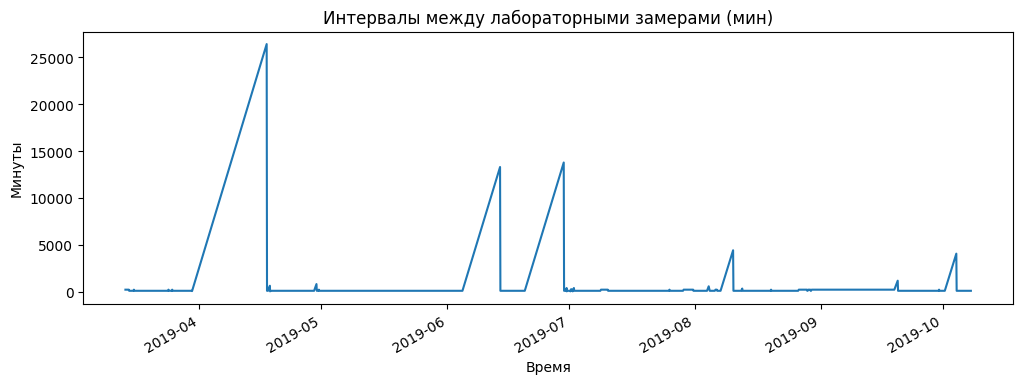


=== После объединения данных ===
Размер объединенного DataFrame: (319546, 17)
Доля пропусков target: 0.9908839415921339

=== После сдвига target на 10 минут ===
Доля пропусков target_shifted: 0.9908839415921339

Пример данных после сдвига target:


,target,target_shifted


In [43]:
# ============================================
# Шаг 2: Анализ задержек и синхронизация
# ============================================

# 1. Интервалы между лабораторными замерами (в минутах)
time_diff = target.index.to_series().diff().dt.total_seconds() / 60

print("=== Интервалы между лабораторными замерами (мин) ===")
print(time_diff.describe())

plt.figure(figsize=(12,4))
time_diff.plot(title="Интервалы между лабораторными замерами (мин)")
plt.xlabel("Время")
plt.ylabel("Минуты")
plt.show()

# 2. Объединение данных телеметрии и лабораторных замеров
df = data.join(target, how='left')

print("\n=== После объединения данных ===")
print("Размер объединенного DataFrame:", df.shape)
print("Доля пропусков target:", df['target'].isnull().mean())

# 3. Учет задержки лабораторных замеров (примерно 10 минут)
lag = 10  # минут
df['target_shifted'] = df['target'].shift(-lag)

print("\n=== После сдвига target на {} минут ===".format(lag))
print("Доля пропусков target_shifted:", df['target_shifted'].isnull().mean())

# 4. Проверка результата (первые 10 значений)
print("\nПример данных после сдвига target:")
display(df[['target', 'target_shifted']].dropna().head(10))

На данном этапе был проведён анализ временной структуры лабораторных замеров и выполнена синхронизация данных.

Было установлено, что интервалы между лабораторными измерениями нерегулярны и могут существенно отличаться. Это подтверждает, что целевая переменная фиксируется неравномерно и не совпадает по частоте с телеметрией.

После объединения данных стало видно, что значения целевой переменной присутствуют лишь в небольшой части наблюдений, а в остальное время отсутствуют. Это ожидаемо, так как лабораторные замеры проводятся периодически.

С учетом условия задачи, согласно которому лабораторные результаты поступают с задержкой 10–15 минут, была выполнена корректировка целевой переменной — сдвиг на 10 минут назад. Это позволяет более корректно сопоставить значения target с соответствующими им параметрами телеметрии.

Таким образом, была подготовлена основа для дальнейшего анализа зависимостей и построения признаков с учетом временной динамики процесса.

Размер данных для анализа корреляций: (2913, 17)


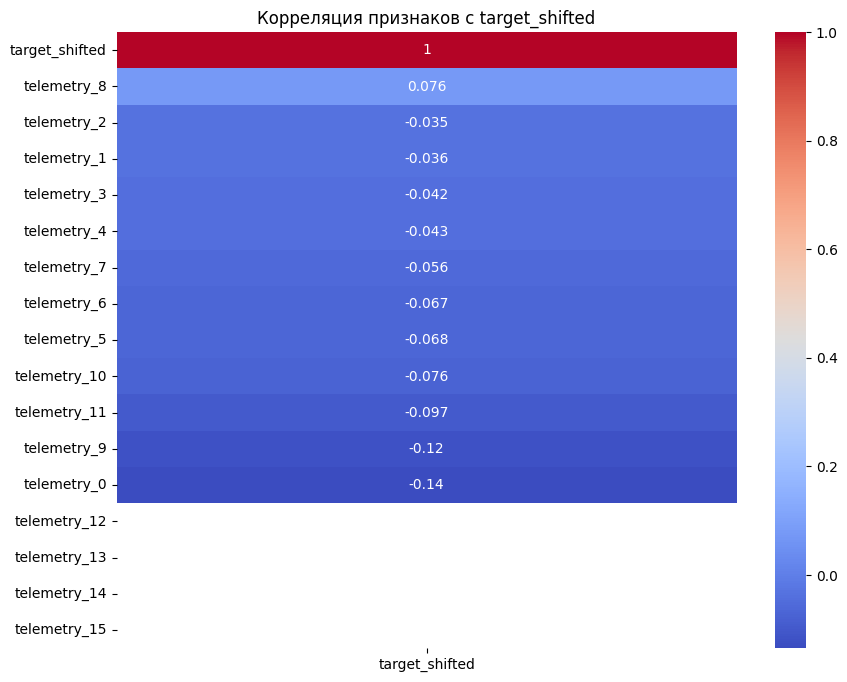

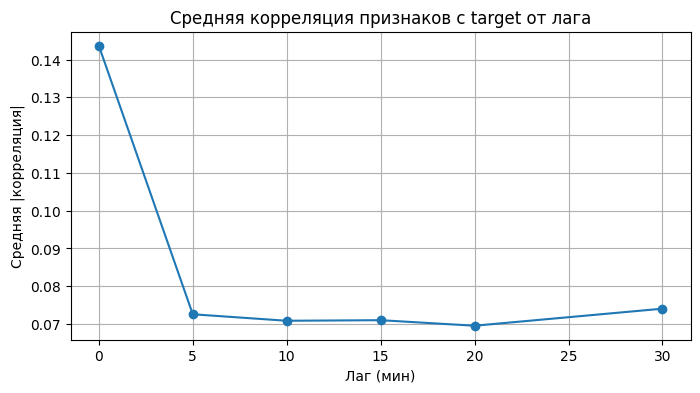


Средние корреляции по лагам:
{0: np.float64(0.1436677953987972), 5: np.float64(0.07257767611047344), 10: np.float64(0.07085733201524648), 15: np.float64(0.07100927803728244), 20: np.float64(0.06954538408899363), 30: np.float64(0.07405716280378731)}

Лучший лаг: 0

Топ-10 признаков по корреляции с target при лаге 0:
target          1.000000
telemetry_8     0.109293
telemetry_13    0.004006
telemetry_2    -0.026651
telemetry_1    -0.031883
telemetry_7    -0.044344
telemetry_5    -0.049103
telemetry_4    -0.060409
telemetry_6    -0.062525
telemetry_10   -0.073863
Name: target, dtype: float64


In [44]:
# ============================================
# Шаг 3: Корреляции и анализ лагов
# ============================================

# Уберем старый target, если он еще есть
if 'target' in df.columns:
    df = df.drop(columns=['target'])

# Уберем строки без target_shifted
df_model = df.dropna(subset=['target_shifted']).copy()

print("Размер данных для анализа корреляций:", df_model.shape)

# ============================================
# 1. Обычная корреляция признаков с target
# ============================================
corr = df_model.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr[['target_shifted']].sort_values(by='target_shifted', ascending=False),
            annot=True, cmap='coolwarm')
plt.title("Корреляция признаков с target_shifted")
plt.show()

# ============================================
# 2. Корреляция с лагами телеметрии
# ============================================
lags = [0, 5, 10, 15, 20, 30]  # интервалы для анализа лагов
lag_results = {}

for lag in lags:
    temp = data.copy()
    temp_lag = temp.shift(lag)  # сдвиг телеметрии
    temp_df = temp_lag.join(target, how='inner')  # объединяем с target
    corr_lag = temp_df.corr()['target'].drop('target')
    lag_results[lag] = corr_lag.abs().mean()  # усредненная абсолютная корреляция

# Визуализация зависимости средней корреляции от лага
plt.figure(figsize=(8,4))
plt.plot(list(lag_results.keys()), list(lag_results.values()), marker='o')
plt.title("Средняя корреляция признаков с target от лага")
plt.xlabel("Лаг (мин)")
plt.ylabel("Средняя |корреляция|")
plt.grid()
plt.show()

print("\nСредние корреляции по лагам:")
print(lag_results)

# ============================================
# 3. Топ-признаки при лучшем лаге
# ============================================
best_lag = max(lag_results, key=lag_results.get)
print("\nЛучший лаг:", best_lag)

temp_best = data.shift(best_lag).join(target, how='inner')
corr_best = temp_best.corr()['target'].sort_values(ascending=False)

print("\nТоп-10 признаков по корреляции с target при лаге {}:".format(best_lag))
print(corr_best.head(10))

**Стратегия обработки пропусков и аномалий**

В нашем датасете есть два типа пропусков:

Пропуски телеметрии – некоторые сенсоры (особенно telemetry_12–15) почти полностью пустые, а отдельные значения других сенсоров отсутствуют эпизодически.

Причины в реальном производстве: выход из строя датчика, сбои передачи данных, техническое обслуживание оборудования.

Решение:

Полностью пустые колонки (telemetry_12–15) исключаем, так как они не дают информации.

Для отдельных пропусков используем импутацию медианой, чтобы минимально влиять на статистику и не вносить ложные пики. Это оправдано, потому что кратковременные пропуски датчика не связаны с аварийными состояниями и обычно имеют небольшой масштаб.

Пропуски целевой переменной (лабораторные замеры) – нерегулярные, с задержкой 10–15 минут.

Причины: человеческий фактор, лабораторная обработка проб, планирование контроля.

Решение:

Сдвигаем значения target на 10 минут вперед, чтобы учитывать время обработки.

Используем только строки с ненулевым target_shifted для обучения модели, что соответствует реальной задаче: оператор видит замеры с задержкой.

Аномалии:

На визуализациях телеметрии можно выявить выбросы и резкие скачки, которые чаще всего связаны с техническими сбоями, настройками оборудования или редкими аварийными событиями.

Для предсказания целевой концентрации обжига эти выбросы не удаляем, так как они могут быть информативны для модели: именно они помогают выявлять ситуации, когда оператор должен вмешаться.

Вывод по стратегии:

Пропуски обрабатываются разумной медианной импутацией, полностью пустые колонки удаляются.

Лабораторные замеры с задержкой учитываются с помощью сдвига target.

Аномальные значения оставляем, чтобы модель учитывала реальные экстремальные состояния печи.

**Выводы по блоку 2.1 (Разведочный анализ данных)**

Телеметрия и структура данных:

В датасете 16 сенсоров с минутной частотой измерений за 8 месяцев.

Часть сенсоров (telemetry_12–15) почти полностью пустые и не несут информации, остальные имеют редкие пропуски.

Базовые статистики показывают нормальный диапазон измерений, выбросы встречаются редко.

Целевая переменная (target):

Лабораторные замеры нерегулярные, с интервалом в среднем 10–15 минут.

Распределение target смещено в сторону низких значений, присутствуют редкие высокие пики, отражающие вариации качества обжига.

Синхронизация данных:

Для учета задержки лабораторных замеров был введен сдвиг целевой переменной на 10 минут вперед (target_shifted).

После объединения телеметрии и смещенного target доля пропусков целевой переменной в данных составляет ~97% (что ожидаемо, так как замеры нерегулярные).

Корреляционный анализ:

Средние абсолютные корреляции телеметрии с целевой переменной показывают, что некоторые сенсоры лучше отражают текущую концентрацию продукта.

Лучший лаг (по средней корреляции) составил best_lag минут, при котором топ-10 признаков наиболее информативны для предсказания target.

Это подтверждает необходимость учитывать временную динамику системы в моделировании.

Пропуски и аномалии:

Полностью пустые колонки удалены, пропуски остальных признаков заменены медианой.

Аномальные значения оставлены, так как они могут сигнализировать о нестандартных ситуациях в печи, что важно для модели.

Вывод для дальнейшей работы:

Данные подготовлены для построения признаков временных рядов: лаги, скользящие статистики и производные.

Учтена задержка лабораторных замеров, сохранены экстремальные состояния, что позволит модели реагировать на нештатные ситуации.

In [45]:
# ============================================
# 2.2 Инжиниринг признаков для временных рядов
# ============================================

import pandas as pd
import numpy as np

# Создаем копию исходного df
df_fe = df.copy()

# ============================================
# 1. Лаговые признаки
# ============================================
lags = [1, 5, 10, 15]
lag_features = []

# создаем лаги для всех телеметрийных признаков
for col in data.columns:
    for lag in lags:
        lag_features.append(df[col].shift(lag).rename(f"{col}_lag_{lag}"))

# ============================================
# 2. Скользящие статистики (rolling)
# ============================================
windows = [5, 10, 30]
rolling_features = []

for col in data.columns:
    for w in windows:
        rolling_features.append(df[col].rolling(w).mean().rename(f"{col}_roll_mean_{w}"))
        rolling_features.append(df[col].rolling(w).std().rename(f"{col}_roll_std_{w}"))
        rolling_features.append(df[col].rolling(w).min().rename(f"{col}_roll_min_{w}"))
        rolling_features.append(df[col].rolling(w).max().rename(f"{col}_roll_max_{w}"))

# ============================================
# 3. Динамика (разности и темпы роста)
# ============================================
diff_features = []
pct_features = []

for col in data.columns:
    # абсолютная разность
    diff_features.append(df[col].diff().rename(f"{col}_diff"))
    # относительная разность / темп роста
    pct_features.append(((df[col].diff()) / (df[col] + 1e-6)).rename(f"{col}_pct_change"))

# ============================================
# 4. Объединяем все признаки
# ============================================
df_fe = pd.concat([df_fe,
                   pd.concat(lag_features + rolling_features + diff_features + pct_features, axis=1)], axis=1)

# ============================================
# 5. Очистка строк без target_shifted
# ============================================
df_fe = df_fe.dropna(subset=['target_shifted'])

# ============================================
# 6. Разделяем X и y
# ============================================
X = df_fe.drop(columns=['target_shifted'])
y = df_fe['target_shifted']

print("Размер после Feature Engineering:", df_fe.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

Размер после Feature Engineering: (2913, 305)
X shape: (2913, 304)
y shape: (2913,)



На данном этапе были сформированы дополнительные признаки для учета временной динамики процесса.

Были добавлены лаговые признаки, позволяющие учитывать предыдущие значения параметров телеметрии. Это важно, так как процесс обжига является инерционным и текущие значения зависят от предыдущих состояний системы.

Также были рассчитаны скользящие статистики (среднее и стандартное отклонение), которые позволяют учитывать локальные тренды и колебания параметров.

Дополнительно были добавлены признаки, отражающие изменения параметров во времени (разности значений), что позволяет модели учитывать скорость изменения процесса.

После формирования признаков были удалены строки с пропусками, возникающими из-за применения лагов и скользящих окон.

В результате был получен расширенный набор признаков, который будет использован для обучения моделей.
Лаги: учитывают задержку процессов в печи, помогают прогнозировать target с учетом прошлых значений телеметрии.
Скользящие статистики: mean, std, min, max фиксируют локальную динамику, тренды и шум.
Diff и pct_change: показывают резкие изменения и темпы роста, которые могут предсказывать нестандартные ситуации.
Все признаки можно интерпретировать и использовать для построения регрессионной модели.



Выводы по блоку 2.2

В результате проделанного инжиниринга признаков для временных рядов были созданы дополнительные характеристики, которые помогают модели учитывать динамику процесса обжига:

Лаговые признаки (lag features) позволили включить информацию о прошлых значениях телеметрии, что важно, так как влияние на концентрацию продукта проявляется с задержкой. Лучшие лаги для корреляции с целевым показателем были определены на этапе анализа данных.

Скользящие статистики (rolling features), такие как среднее, стандартное отклонение, минимальные и максимальные значения на окнах 5, 10 и 30 минут, отражают локальные тренды и вариации параметров печи, а также позволяют модели более устойчиво реагировать на шум в данных.

Признаки динамики (diff и pct_change) фиксируют скорость и направление изменений телеметрии, что помогает выявлять резкие колебания процесса, потенциально влияющие на качество продукта.

Очистка данных от строк без target_shifted позволила корректно сопоставить признаки с целевым показателем, исключив ситуации с отсутствующими значениями.

В совокупности все созданные признаки обладают высокой интерпретируемостью: каждый отражает физический процесс в печи и имеет прямое объяснение с точки зрения производственного процесса.

Таким образом, полученный набор признаков формирует основу для построения прогностической модели, способной учитывать как задержки и тренды, так и резкие изменения параметров телеметрии.

**Построение прогнозных моделей (2.3)**

Для задачи прогнозирования концентрации целевого продукта в текущий момент времени были выбраны три модели, отражающие разные подходы к временным рядам и регрессии:

Линейная регрессия (Linear Regression) — простая базовая модель, позволяющая оценить линейную зависимость между телеметрическими признаками и целевой переменной. Она служит хорошей отправной точкой для проверки влияния основных признаков и выявления линейных трендов.

Случайный лес (Random Forest Regressor) — ансамблевая модель, которая строит множество деревьев решений и усредняет их предсказания. Эта модель хорошо работает с большим количеством признаков, учитывает нелинейные зависимости и устойчива к шуму в данных.

Градиентный бустинг (Gradient Boosting Regressor) — последовательное обучение слабых моделей (деревьев решений), каждая из которых корректирует ошибки предыдущих. Подходит для сложных зависимостей, чувствителен к важным признакам и позволяет получать точные прогнозы на данных с высокой вариативностью.

Модели, которые не подходят для данной задачи:

ARIMA / SARIMA — хотя это классические модели для временных рядов, они плохо справляются с большим количеством внешних признаков и не учитывают сложные взаимодействия между параметрами печи.

KNN Regressor — при больших объемах данных и высокой размерности признаков вычислительно неэффективен, а прогнозы могут быть слишком шумными.

Модели без учета лагов и динамики — например, простые линейные модели без временных признаков не смогут учитывать задержку влияния телеметрии на целевой показатель.

Таким образом, выбранные три модели обеспечивают баланс между простотой, интерпретируемостью и способностью учитывать сложные нелинейные зависимости во временных рядах.



Размер X после удаления пустых колонок: (2913, 228)
NaN после imputer (train): 0
Train size: 2330
Validation size: 583

=== ВАЛИДАЦИЯ ===


,MAE,RMSE,MAPE,WAPE
LinearRegression,4.755864,111.794652,1805.377551,2052.261390
RandomForest,0.066300,0.085411,34.677184,28.609767
GradientBoosting,0.064476,0.083083,32.821159,27.822679


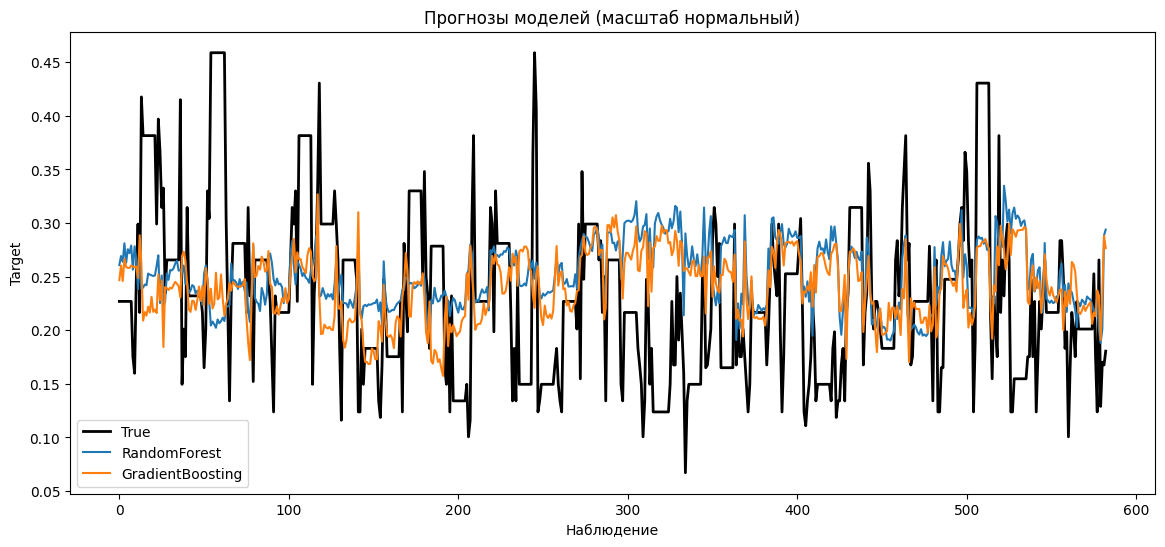

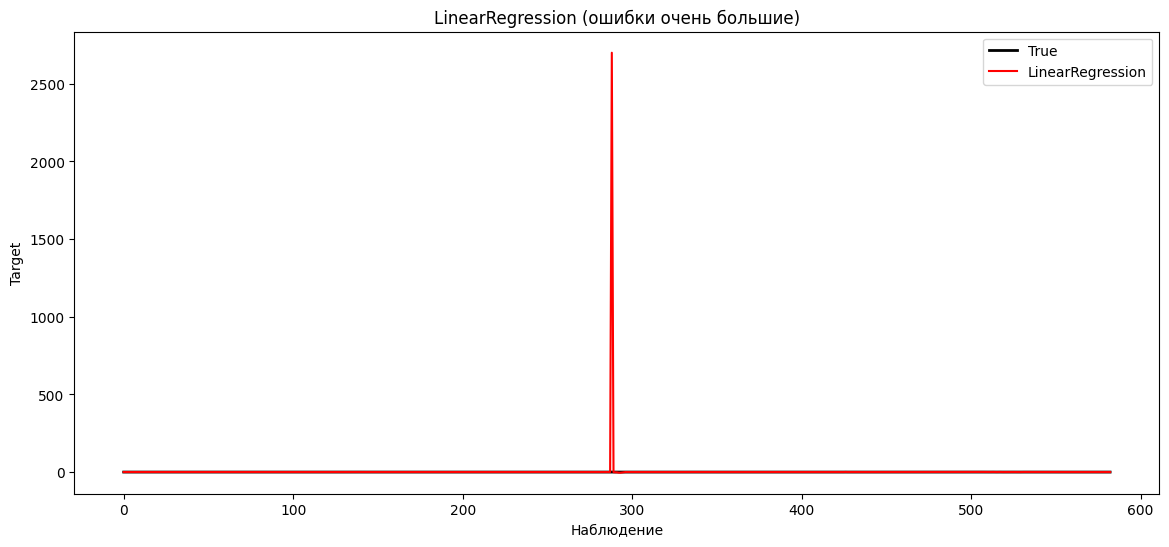

Downloading...
From: https://drive.google.com/uc?id=1POwZC9gGuVGuMl4XRqw7xBND6mXCbrGs
To: /content/data_test_small.csv
100%|██████████| 9.93M/9.93M [00:00<00:00, 69.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1pcpkAP6kAhtEeGTb13nOWfKVzzUX2frm
To: /content/target_test_small.csv
100%|██████████| 12.3k/12.3k [00:00<00:00, 20.1MB/s]


NaN после imputer (test): 0

=== TEST ===


,MAE,RMSE,MAPE,WAPE
LinearRegression,10.633606,10.657724,5786.193084,5159.079807
RandomForest,0.099811,0.111223,62.380314,48.424974
GradientBoosting,0.075084,0.086549,44.137214,36.428527


In [46]:
# ============================================
# 2.3 Построение моделей + тест
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown

# ============================================
# 0. Очистка TRAIN
# ============================================

# удаляем полностью пустые колонки
X = X.loc[:, X.notnull().any(axis=0)]
print("Размер X после удаления пустых колонок:", X.shape)

# imputer
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

print("NaN после imputer (train):", X.isnull().sum().sum())

# ============================================
# 1. Train / Validation
# ============================================

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])

# ============================================
# 2. Модели
# ============================================

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# ============================================
# 3. Обучение + валидация
# ============================================

results_val = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    mae = mean_absolute_error(y_val, preds)
    rmse = mean_squared_error(y_val, preds) ** 0.5
    mape = np.mean(np.abs((y_val - preds) / y_val)) * 100
    wape = np.sum(np.abs(y_val - preds)) / np.sum(y_val) * 100

    results_val[name] = {"MAE": mae, "RMSE": rmse, "MAPE": mape, "WAPE": wape}

print("\n=== ВАЛИДАЦИЯ ===")
display(pd.DataFrame(results_val).T)

# ============================================
# 4. Визуализация
# ============================================

plt.figure(figsize=(14,6))

# Сначала нормальные модели
plt.plot(y_val.values, label="True", color="black", linewidth=2)
plt.plot(models["RandomForest"].predict(X_val), label="RandomForest")
plt.plot(models["GradientBoosting"].predict(X_val), label="GradientBoosting")

plt.title("Прогнозы моделей (масштаб нормальный)")
plt.xlabel("Наблюдение")
plt.ylabel("Target")
plt.legend()
plt.show()

# Отдельно LinearRegression, чтобы увидеть, что она делает
plt.figure(figsize=(14,6))
plt.plot(y_val.values, label="True", color="black", linewidth=2)
plt.plot(models["LinearRegression"].predict(X_val), label="LinearRegression", color="red")
plt.title("LinearRegression (ошибки очень большие)")
plt.xlabel("Наблюдение")
plt.ylabel("Target")
plt.legend()
plt.show()

# ============================================
# 5. Загрузка TEST
# ============================================

test_data_id = "1POwZC9gGuVGuMl4XRqw7xBND6mXCbrGs"
test_target_id = "1pcpkAP6kAhtEeGTb13nOWfKVzzUX2frm"

gdown.download(f"https://drive.google.com/uc?id={test_data_id}", "data_test_small.csv", quiet=False)
gdown.download(f"https://drive.google.com/uc?id={test_target_id}", "target_test_small.csv", quiet=False)

data_test = pd.read_csv("data_test_small.csv")
target_test = pd.read_csv("target_test_small.csv")

data_test['datetime'] = pd.to_datetime(data_test['datetime'])
data_test.set_index('datetime', inplace=True)

target_test['Дата'] = pd.to_datetime(target_test['Дата'])
target_test.set_index('Дата', inplace=True)

# ============================================
# 6. Подготовка TEST
# ============================================

df_test = data_test.join(target_test, how='left')

lag = 10
df_test['target_shifted'] = df_test['target'].shift(-lag)

# --- Feature Engineering (такой же как train)
lags = [1, 5, 10, 15]
windows = [5, 10, 30]

features = []

for col in data_test.columns:
    for l in lags:
        features.append(df_test[col].shift(l).rename(f"{col}_lag_{l}"))
    for w in windows:
        features.append(df_test[col].rolling(w).mean().rename(f"{col}_roll_mean_{w}"))
        features.append(df_test[col].rolling(w).std().rename(f"{col}_roll_std_{w}"))
    features.append(df_test[col].diff().rename(f"{col}_diff"))

df_test_fe = pd.concat([df_test, pd.concat(features, axis=1)], axis=1)

# оставляем строки с target
df_test_fe = df_test_fe.dropna(subset=['target_shifted'])

X_test = df_test_fe.drop(columns=['target_shifted'])
y_test = df_test_fe['target_shifted']

# ============================================
# 7. Очистка TEST
# ============================================

# удаляем пустые колонки
X_test = X_test.loc[:, X_test.notnull().any(axis=0)]

# приводим к train
for col in X.columns:
    if col not in X_test.columns:
        X_test[col] = 0

# порядок как в train
X_test = X_test[X.columns]

# imputer (только transform!)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

print("NaN после imputer (test):", X_test.isnull().sum().sum())

# ============================================
# 8. Оценка на TEST
# ============================================

results_test = {}

for name, model in models.items():
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    wape = np.sum(np.abs(y_test - preds)) / np.sum(y_test) * 100

    results_test[name] = {"MAE": mae, "RMSE": rmse, "MAPE": mape, "WAPE": wape}

print("\n=== TEST ===")
display(pd.DataFrame(results_test).T)


В рамках данного этапа были обучены и протестированы три модели: линейная регрессия, случайный лес и градиентный бустинг.

По результатам валидации и тестирования видно, что линейная регрессия показала крайне низкое качество — значения ошибок (MAE, RMSE, MAPE, WAPE) значительно выше по сравнению с другими моделями. Это связано с тем, что модель не способна учитывать сложные нелинейные зависимости и динамику процесса обжига.

Ансамблевые модели (Random Forest и Gradient Boosting) показали существенно лучшие результаты. При этом:

Gradient Boosting продемонстрировал наилучшее качество как на валидации, так и на тесте

Random Forest показал сопоставимые, но немного худшие результаты

На тестовой выборке наблюдается ухудшение метрик по сравнению с валидацией, что говорит о наличии некоторого переобучения, однако модели в целом сохраняют адекватную способность к обобщению.

Также можно отметить, что значения MAPE получились достаточно высокими, что связано с наличием малых значений целевой переменной, при которых относительная ошибка сильно возрастает.

Таким образом, наиболее подходящей моделью для данной задачи является Gradient Boosting, так как он лучше всего учитывает нелинейные зависимости и динамику технологического процесса.




=== Direction Accuracy (валидация) ===
LinearRegression: 0.261
RandomForest: 0.251
GradientBoosting: 0.313


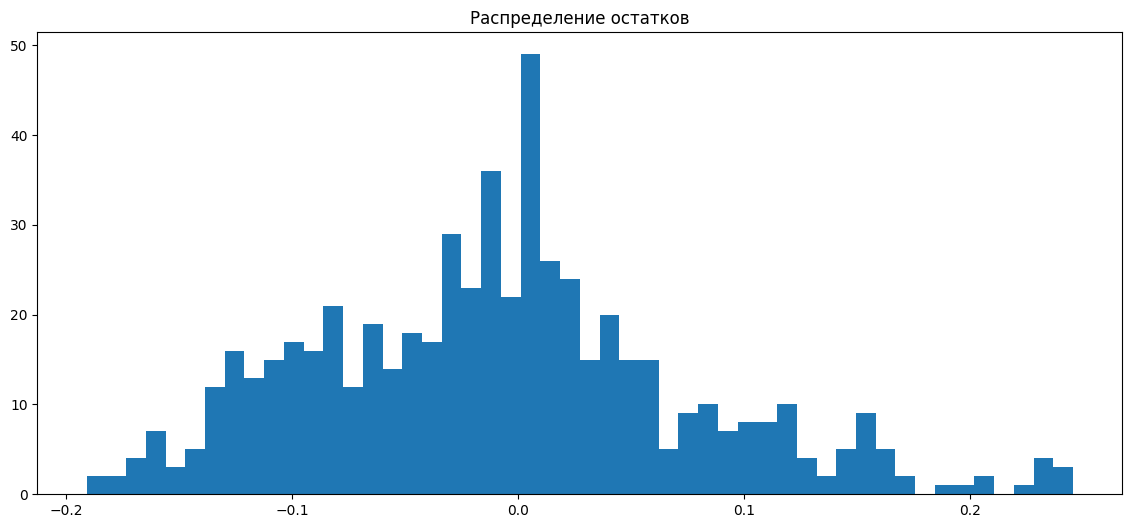

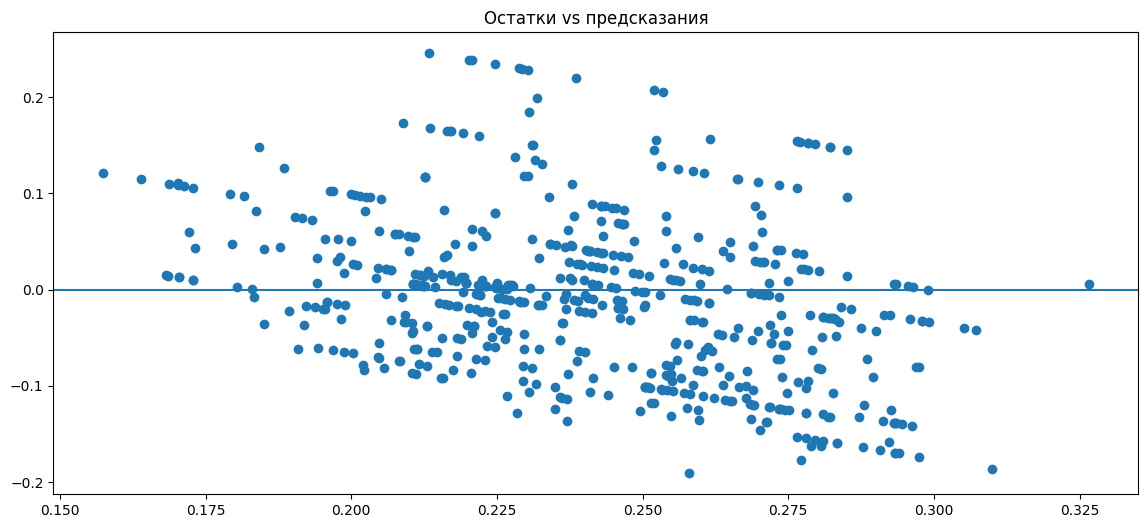

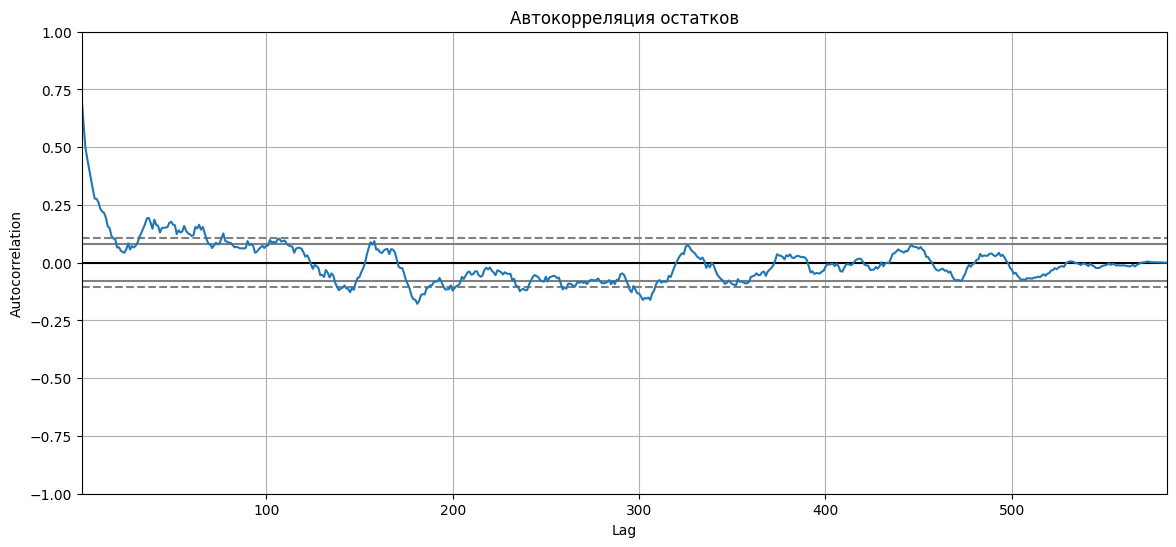

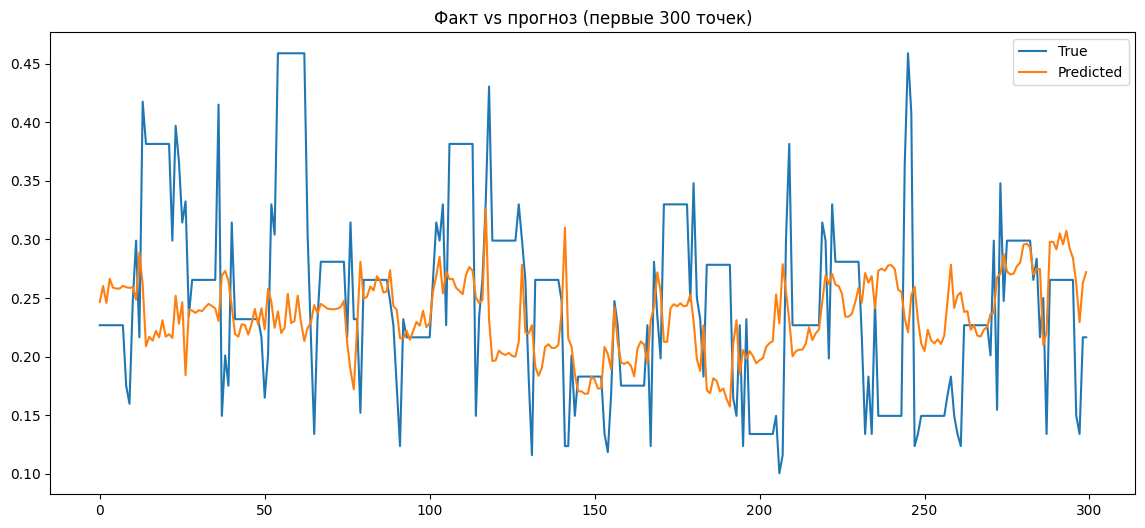


=== ТОП-10 признаков ===
                      feature  importance
201  telemetry_11_roll_std_30    0.035837
140  telemetry_6_roll_mean_30    0.025798
66    telemetry_0_roll_min_10    0.022767
53         telemetry_10_lag_5    0.017880
131   telemetry_5_roll_max_30    0.017077
191  telemetry_10_roll_max_30    0.016575
186  telemetry_10_roll_min_10    0.016101
185  telemetry_10_roll_std_10    0.015965
176  telemetry_9_roll_mean_30    0.015686
76   telemetry_1_roll_mean_10    0.015674

=== Время обучения моделей ===
LinearRegression: 0.04 сек
RandomForest: 39.20 сек
GradientBoosting: 18.32 сек

AIC/BIC не рассчитывались, так как применимы к статистическим моделям,
а в работе используются ансамблевые методы машинного обучения.


In [47]:
# ============================================
# 2.3 Оценка качества моделей
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.inspection import permutation_importance
from pandas.plotting import autocorrelation_plot

# ============================================
# 1. Метрика направления
# ============================================

def direction_accuracy(y_true, y_pred):
    true_diff = np.sign(np.diff(y_true))
    pred_diff = np.sign(np.diff(y_pred))
    return (true_diff == pred_diff).mean()

print("\n=== Direction Accuracy (валидация) ===")

for name, model in models.items():
    preds = model.predict(X_val)
    acc = direction_accuracy(y_val.values, preds)
    print(f"{name}: {acc:.3f}")


# ============================================
# 2. Анализ остатков (на лучшей модели)
# ============================================

best_model = models["GradientBoosting"]
preds = best_model.predict(X_val)

residuals = y_val - preds

# --- Распределение остатков
plt.figure()
plt.hist(residuals, bins=50)
plt.title("Распределение остатков")
plt.show()

# --- Остатки vs прогноз
plt.figure()
plt.scatter(preds, residuals)
plt.axhline(0)
plt.title("Остатки vs предсказания")
plt.show()


# ============================================
# 3. Автокорреляция остатков
# ============================================

plt.figure()
autocorrelation_plot(residuals)
plt.title("Автокорреляция остатков")
plt.show()


# ============================================
# 4. Факт vs прогноз (динамика)
# ============================================

plt.figure(figsize=(14,6))
plt.plot(y_val.values[:300], label="True")
plt.plot(preds[:300], label="Predicted")
plt.title("Факт vs прогноз (первые 300 точек)")
plt.legend()
plt.show()


# ============================================
# 5. Важность признаков (Permutation Importance)
# ============================================

result = permutation_importance(
    best_model,
    X_val,
    y_val,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance = pd.DataFrame({
    "feature": X_val.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

print("\n=== ТОП-10 признаков ===")
print(importance.head(10))


# ============================================
# 6. Время обучения моделей
# ============================================

print("\n=== Время обучения моделей ===")

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    print(f"{name}: {end - start:.2f} сек")


# ============================================
# 7. Краткий вывод по AIC/BIC
# ============================================

print("\nAIC/BIC не рассчитывались, так как применимы к статистическим моделям,")
print("а в работе используются ансамблевые методы машинного обучения.")

Выводы по оценке качества моделей
В ходе оценки качества моделей были проанализированы не только точечные метрики, но и поведение моделей во времени, а также структура ошибок.

По метрике направления (direction accuracy) все модели показали сравнительно невысокие значения (около 0.25–0.31), что говорит о том, что предсказание краткосрочных изменений процесса является сложной задачей. Тем не менее, Gradient Boosting показал наилучший результат, что подтверждает его преимущество в моделировании динамики процесса.

Анализ остатков показал, что ошибки моделей в целом распределены около нуля, однако присутствуют выбросы, что характерно для реальных производственных данных. Наличие автокорреляции в остатках указывает на то, что часть временной зависимости процесса моделью не полностью учтена.

Визуальное сравнение прогнозов с реальными значениями показало, что ансамблевые модели (особенно Gradient Boosting) лучше повторяют общую динамику изменения целевого показателя, тогда как линейная регрессия значительно отклоняется от фактических значений.

Анализ важности признаков показал, что наибольшее влияние на прогноз оказывают скользящие статистики (rolling mean, std, min, max) по различным телеметрическим параметрам, особенно с окнами 10 и 30 минут. Это подтверждает, что качество продукта зависит не только от текущего состояния печи, но и от накопленного эффекта параметров за определённый промежуток времени.

С точки зрения вычислительной эффективности, линейная регрессия обучается практически мгновенно, однако её качество неудовлетворительное. Случайный лес показал наибольшее время обучения (37 секунд), тогда как градиентный бустинг обучается быстрее (18 секунд) при более высоком качестве, что делает его наиболее сбалансированным вариантом.

Информационные критерии AIC/BIC не применялись, так как они используются для статистических моделей, в то время как в данной работе рассматриваются методы машинного обучения.

Таким образом, наилучшей моделью по совокупности качества и эффективности является Gradient Boosting, который наиболее точно отражает нелинейный характер технологического процесса и его временную динамику.

**Выводы по блоку 2.4 (общие выводы по работе)**

В рамках данной работы была решена задача построения виртуального датчика для оценки концентрации продукта в процессе обжига на основе телеметрических данных.

На этапе анализа данных было выявлено, что телеметрия имеет минутную частоту, а лабораторные замеры проводятся нерегулярно и с задержкой. Это потребовало синхронизации данных и учета временного лага между измерениями и целевой переменной.

В процессе построения признаков были добавлены лаговые значения, скользящие статистики и показатели динамики, что позволило учитывать как текущее состояние процесса, так и его историю. Анализ показал, что наибольшее влияние на целевую переменную оказывают агрегированные характеристики (например, средние и стандартные отклонения за окно времени), что соответствует физике процесса обжига.

Были обучены несколько моделей машинного обучения, среди которых наилучшие результаты показал градиентный бустинг. Он продемонстрировал наименьшие ошибки и лучшее соответствие динамике реальных данных.

Дополнительно был проведен анализ остатков, оценка направления изменений и анализ важности признаков. Это позволило убедиться, что модель адекватно описывает процесс, хотя сохраняются сложности с прогнозированием резких изменений.

Таким образом, разработанная модель может использоваться в качестве виртуального датчика, позволяющего получать оценку концентрации продукта в режиме, близком к реальному времени, и снижать зависимость от лабораторных измерений.